### Importing Libraries

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import *

### Defining Indices

In [2]:
# Indices for factory
I = ['F1', 'F2', 'F3']
# Indices for warehouses
J = ['W1','W2','W3','W4','W5'] 
# Indices for customers
K = ['d1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10'] 

### Defining Parameters and its values

In [3]:
factory_capacity = {'F1': 1100, 'F2': 800, 'F3': 950}
warehouse_capacity = {'W1': 650, 'W2': 350, 'W3': 700, 'W4': 300, 'W5': 400}

# Fixed Cost to operate each warehouse
fixed_cost = {'W1': 2500, 'W2': 3000, 'W3': 2800, 'W4': 2200, 'W5': 3500}

# Demand at customers end
d = {'d1':120, 'd2':150, 'd3':180, 'd4':140, 'd5':130, 'd6':160, 'd7':170, 'd8':140, 'd9':190, 'd10':120} 

# Cost of transportation from factory to warehouse
cost_fw = {('F1','W1'):4, ('F1','W2'):6, ('F1','W3'):9, ('F1','W4'):5, ('F1','W5'):8, 
           ('F2','W1'):5, ('F2','W2'):4, ('F2','W3'):7, ('F2','W4'):6, ('F2','W5'):5, 
           ('F3','W1'):8, ('F3','W2'):5, ('F3','W3'):4, ('F3','W4'):7, ('F3','W5'):3} 

# Cost of transportation from warehouse to customer
cost_wc = {('W1','d1'):3, ('W1','d2'):4, ('W1','d3'):6, ('W1','d4'):5, ('W1','d5'):7, 
           ('W1','d6'):8, ('W1','d7'):6, ('W1','d8'):5, ('W1','d9'):9, ('W1','d10'):7, 
           
           ('W2','d1'):5, ('W2','d2'):3, ('W2','d3'):4, ('W2','d4'):7,('W2','d5'):5, 
           ('W2','d6'):6, ('W2','d7'):7, ('W2','d8'):4, ('W2','d9'):8, ('W2','d10'):6,
           
           ('W3','d1'):8, ('W3','d2'):7, ('W3','d3'):3, ('W3','d4'):4, ('W3','d5'):5,
           ('W3','d6'):4, ('W3','d7'):5, ('W3','d8'):6, ('W3','d9'):4, ('W3','d10'):7,
           
           ('W4','d1'):6, ('W4','d2'):5, ('W4','d3'):7, ('W4','d4'):3, ('W4','d5'):4,
           ('W4','d6'):5, ('W4','d7'):6, ('W4','d8'):4, ('W4','d9'):7, ('W4','d10'):5,
           
           ('W5','d1'):7, ('W5','d2'):6, ('W5','d3'):5, ('W5','d4'):4, ('W5','d5'):3, 
           ('W5','d6'):4, ('W5','d7'):3, ('W5','d8'):5, ('W5','d9'):4, ('W5','d10'):6} 


In [4]:
sum(factory_capacity.values())

2850

### Defining MILP Model

In [5]:
model = Model(name ='facility location MILP')

Restricted license - for non-production use only - expires 2027-11-29


### Defining Decision Variables

In [6]:
# Quantity transported from factory i to warehouse j.
x = model.addVars(I, J, name='x', vtype = GRB.CONTINUOUS, lb=0)
# Quantity transported from warehouse j to customer k.
y = model.addVars(J, K, name='y', vtype = GRB.CONTINUOUS, lb=0) 
# Binary variable indicating whether warehouse j is opened
z = model.addVars(J, name = 'z', vtype = GRB.BINARY) 

### Defining Objective Function

In [7]:
obj_fn = (quicksum (x[i, j]*cost_fw[i, j] for i in I for j in J) + 
          quicksum (y[j, k]*cost_wc[j, k] for j in J for k in K) + 
          quicksum (z[j] * fixed_cost[j] for j in J))

model.setObjective(obj_fn, GRB.MINIMIZE)

### Defining Contraints to Objective function

In [8]:
# Factory capacity constraints
for i in I:
    model.addConstr(quicksum(x[i, j] for j in J) <= factory_capacity[i], name=f"FactoryCap_{i}")

In [9]:
# Warehouse capacity constraints
for j in J:
    model.addConstr(quicksum(x[i, j] for i in I) <= warehouse_capacity[j]*z[j], name=f"WareHouseCap_{j}")

In [10]:
# Customer demand satisfaction
for k in K:
    model.addConstr(quicksum(y[j, k] for j in J)*z[j] == d[k], name=f"DemandFull_{k}")

In [11]:
# Flow balance constraints
for j in J:
    model.addConstr(quicksum(x[i, j] for i in I) == quicksum(y[j, k] for k in K), name=f"FlowBal_{j}")

### Optimizing the solutions

In [12]:
model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 13 rows, 70 columns and 100 nonzeros (Min)
Model fingerprint: 0x2ff49905
Model has 70 linear objective coefficients
Model has 10 quadratic constraints
Variable types: 65 continuous, 5 integer (5 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+02]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [3e+00, 4e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+02, 1e+03]
  QRHS range       [1e+02, 2e+02]

Presolve added 10 rows and 0 columns
Presolve removed 0 rows and 1 columns
Presolve time: 0.03s
Presolved: 23 rows, 69 columns, 149 nonzeros
Variable types: 65 continuous, 4 integer (4 binary)
Found heuristic solution: objective 25090.000000

Root relaxation: objective 1.933538e+04, 25 iterations, 

### Optimized Results

In [13]:
print('Objective Function Value: %f' %model.objVal)
for Q in model.getVars():
    print('%s: %g' % (Q.varName, Q.x))

Objective Function Value: 20320.000000
x[F1,W1]: 550
x[F1,W2]: 0
x[F1,W3]: 0
x[F1,W4]: 0
x[F1,W5]: 0
x[F2,W1]: 0
x[F2,W2]: 0
x[F2,W3]: 0
x[F2,W4]: 0
x[F2,W5]: 0
x[F3,W1]: 0
x[F3,W2]: 0
x[F3,W3]: 550
x[F3,W4]: 0
x[F3,W5]: 400
y[W1,d1]: 120
y[W1,d2]: 150
y[W1,d3]: 0
y[W1,d4]: 20
y[W1,d5]: 0
y[W1,d6]: 0
y[W1,d7]: 0
y[W1,d8]: 140
y[W1,d9]: 0
y[W1,d10]: 120
y[W2,d1]: 0
y[W2,d2]: 0
y[W2,d3]: 0
y[W2,d4]: 0
y[W2,d5]: 0
y[W2,d6]: 0
y[W2,d7]: 0
y[W2,d8]: 0
y[W2,d9]: 0
y[W2,d10]: 0
y[W3,d1]: 0
y[W3,d2]: 0
y[W3,d3]: 180
y[W3,d4]: 120
y[W3,d5]: 0
y[W3,d6]: 160
y[W3,d7]: 0
y[W3,d8]: 0
y[W3,d9]: 90
y[W3,d10]: 0
y[W4,d1]: 0
y[W4,d2]: 0
y[W4,d3]: 0
y[W4,d4]: 0
y[W4,d5]: 0
y[W4,d6]: 0
y[W4,d7]: 0
y[W4,d8]: 0
y[W4,d9]: 0
y[W4,d10]: 0
y[W5,d1]: 0
y[W5,d2]: 0
y[W5,d3]: 0
y[W5,d4]: 0
y[W5,d5]: 130
y[W5,d6]: 0
y[W5,d7]: 170
y[W5,d8]: 0
y[W5,d9]: 100
y[W5,d10]: 0
z[W1]: 1
z[W2]: -0
z[W3]: 1
z[W4]: -0
z[W5]: 1


In [14]:
non_zero_xij = {(i,j): x[i,j].X for i in I for j in J if x[i,j].X>0.5}
non_zero_xij

{('F1', 'W1'): 550.0, ('F3', 'W3'): 550.0, ('F3', 'W5'): 400.0}

In [15]:
non_zero_yjk = {(j,k): y[j,k].X for j in J for k in K if y[j,k].X>0.5}
non_zero_yjk

{('W1', 'd1'): 120.0,
 ('W1', 'd2'): 150.0,
 ('W1', 'd4'): 20.0,
 ('W1', 'd8'): 140.0,
 ('W1', 'd10'): 120.0,
 ('W3', 'd3'): 180.0,
 ('W3', 'd4'): 120.0,
 ('W3', 'd6'): 160.0,
 ('W3', 'd9'): 90.0,
 ('W5', 'd5'): 130.0,
 ('W5', 'd7'): 170.0,
 ('W5', 'd9'): 100.0}

In [16]:
non_zero_zj = {(j): z[j].X for j in J if z[j].X>0.5}
non_zero_zj

{'W1': 1.0, 'W3': 1.0, 'W5': 1.0}

### Network Visualization

In [17]:
G = nx.DiGraph()

In [18]:
factories = ['F1','F2','F3']
warehouses = ['W1','W2','W3','W4','W5']
customers = ['d1','d2','d3','d4','d5','d6','d7','d8','d9','d10']

G.add_nodes_from(factories)
G.add_nodes_from(warehouses)
G.add_nodes_from(customers)

In [19]:
flows_fw = {
('F1','W1'):300,
('F1','W4'):300,
('F2','W1'):50,
('F2','W5'):150,
('F3','W3'):350,
('F3','W5'):350
}

flows_wc = {
('W1','d1'):120,
('W1','d2'):150,
('W1','d8'):80,

('W3','d3'):180,
('W3','d4'):20,
('W3','d6'):150,

('W4','d4'):120,
('W4','d8'):60,
('W4','d10'):120,

('W5','d5'):130,
('W5','d6'):10,
('W5','d7'):170,
('W5','d9'):190
}

In [20]:
for (u,v),flow in flows_fw.items():
    G.add_edge(u,v,weight=flow)

for (u,v),flow in flows_wc.items():
    G.add_edge(u,v,weight=flow)

In [21]:
pos = {}

for i,f in enumerate(factories):
    pos[f] = (0, -i)

for i,w in enumerate(warehouses):
    pos[w] = (3, -i)

for i,c in enumerate(customers):
    pos[c] = (6, -i)

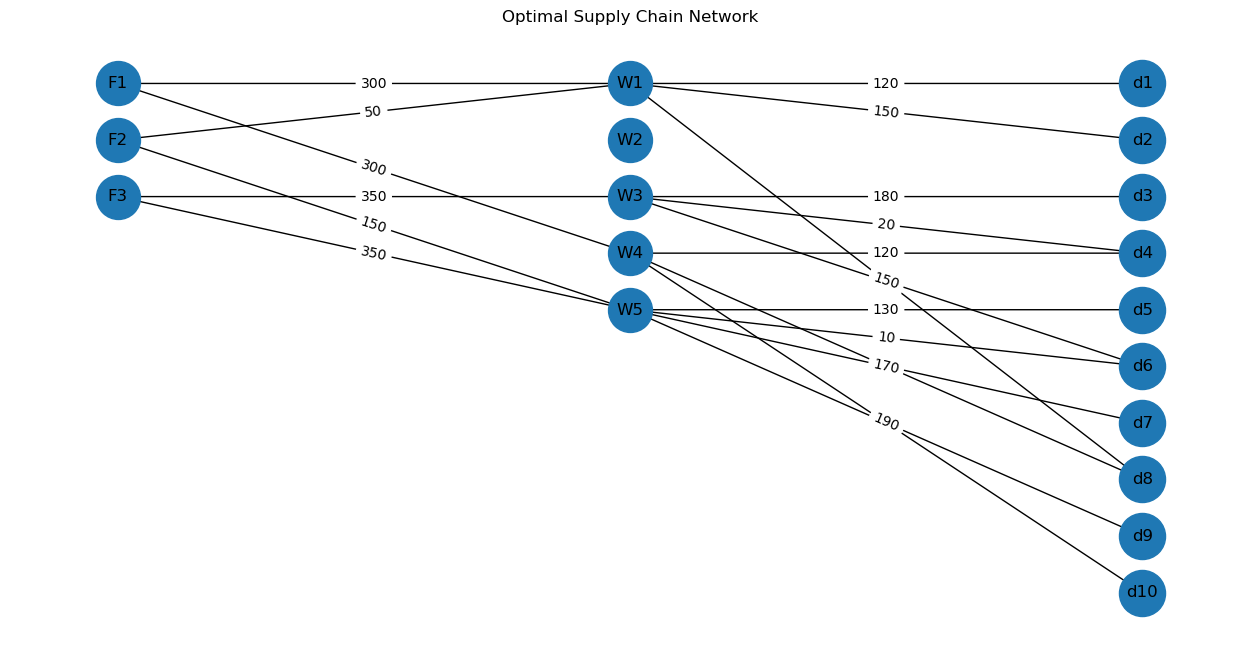

In [22]:
plt.figure(figsize=(16,8))

nx.draw_networkx_nodes(
    G,pos,
    nodelist=factories,
    node_size=1000
)

nx.draw_networkx_nodes(
    G,pos,
    nodelist=warehouses,
    node_size=1000
)

nx.draw_networkx_nodes(
    G,pos,
    nodelist=customers,
    node_size=1100
)

nx.draw_networkx_labels(G,pos)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True
)

edge_labels = nx.get_edge_attributes(G,'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Optimal Supply Chain Network")
plt.axis('off')
plt.show()

## Warehouse Capacity sensitivity analysis

In [34]:
def solve_facility_location(fixed_cost = fixed_cost, warehouse_capacity = warehouse_capacity, 
                            factory_capacity = factory_capacity):

    model = Model()

    # Variables
    x = model.addVars(I, J, name="x")
    y = model.addVars(J, K, name="y")
    z = model.addVars(J, vtype=GRB.BINARY, name="z")

    # Objective
    model.setObjective(
        quicksum(cost_fw[i,j]*x[i,j] for i in I for j in J)
        + quicksum(cost_wc[j,k]*y[j,k] for j in J for k in K)
        + quicksum(fixed_cost[j]*z[j] for j in J),
        GRB.MINIMIZE
    )

    for i in I:
        model.addConstr(quicksum(x[i, j] for j in J) <= factory_capacity[i], name=f"FactoryCap_{i}")
    for j in J:
        model.addConstr(quicksum(x[i, j] for i in I) <= warehouse_capacity[j]*z[j], name=f"WareHouseCap_{j}")
    for k in K:
        model.addConstr(quicksum(y[j, k] for j in J)*z[j] == d[k], name=f"DemandFull_{k}")
    for j in J:
        model.addConstr(quicksum(x[i, j] for i in I) == quicksum(y[j, k] for k in K), name=f"FlowBal_{j}")

    model.optimize()
    
   
    return {
        "Objective": model.ObjVal,
        "Open Warehouses": [j for j in J if z[j].X > 0.5]
    }

### Base Case

In [23]:
warehouse_status = []

for j in J:
    
    if z[j].X > 0.5:
        status = 'Yes'
    else:
        status = 'No'
        
    warehouse_status.append([j, status])

df1 = pd.DataFrame(
    warehouse_status,
    columns=['Warehouse', 'Open']
)

print(df1)

  Warehouse Open
0        W1  Yes
1        W2   No
2        W3  Yes
3        W4   No
4        W5  Yes


### Varying the Fixed Cost

In [56]:
results_for_fix_cost_variation = []

for multiplier in [0.5, 1.0, 2.0, 3.0, 5.0]:

    scenario_cost = {
        w: multiplier*fixed_cost[w]
        for w in J
        }
    print(scenario_cost)
    result = solve_facility_location(fixed_cost = scenario_cost)

    results_for_fix_cost_variation.append({
        "Multiplier": multiplier,
        "Objective": result["Objective"],
        "Open Warehouses": len(result["Open Warehouses"]),
        "Warehouses Selected": result["Open Warehouses"]
        })

{'W1': 1250.0, 'W2': 1500.0, 'W3': 1400.0, 'W4': 1100.0, 'W5': 1750.0}
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 13 rows, 70 columns and 100 nonzeros (Min)
Model fingerprint: 0x09144263
Model has 70 linear objective coefficients
Model has 10 quadratic constraints
Variable types: 65 continuous, 5 integer (5 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+02]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [3e+00, 2e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+02, 1e+03]
  QRHS range       [1e+02, 2e+02]

Presolve added 10 rows and 0 columns
Presolve removed 0 rows and 1 columns
Presolve time: 0.00s
Presolved: 23 rows, 69 columns, 149 nonzeros
Variable types: 65 continuous, 4 integer (4 binary)
Found heuristic solution: objective


    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 50596.9231    0    2 81090.0000 50596.9231  37.6%     -    0s
H    0     0                    55520.000000 50596.9231  8.87%     -    0s
     0     0 50941.4286    0    1 55520.0000 50941.4286  8.25%     -    0s
     0     0 50941.4286    0    2 55520.0000 50941.4286  8.25%     -    0s
     0     0 55520.0000    0    1 55520.0000 55520.0000  0.00%     -    0s

Cutting planes:
  Gomory: 1
  Implied bound: 7
  MIR: 1
  Flow cover: 1
  Relax-and-lift: 1

Explored 1 nodes (54 simplex iterations) in 0.05 seconds (0.00 work units)
Thread count was 8 (of 8 available processors)

Solution count 2: 55520 81090 

Optimal solution found (tolerance 1.00e-04)
Best objective 5.552000000000e+04, best bound 5.552000000000e+04, gap 0.0000%


In [57]:
df2 = pd.DataFrame(results_for_fix_cost_variation)
print(df2)

   Multiplier  Objective  Open Warehouses Warehouses Selected
0         0.5    15920.0                3        [W1, W3, W5]
1         1.0    20320.0                3        [W1, W3, W5]
2         2.0    29120.0                3        [W1, W3, W5]
3         3.0    37920.0                3        [W1, W3, W5]
4         5.0    55520.0                3        [W1, W3, W5]


### Varying the Warehouse Capacity

In [58]:
results_for_war_cap_variation = []

for multiplier in [1.0, 2.0, 3.0, 5.0]:

    scenario_warehouse_capacities = {
        w: multiplier*warehouse_capacity[w]
        for w in J
        }
    print(scenario_warehouse_capacities)
    result = solve_facility_location(warehouse_capacity=scenario_warehouse_capacities)

    results_for_war_cap_variation.append({
        "Multiplier": multiplier,
        "Objective": result["Objective"],
        "Open Warehouses": len(result["Open Warehouses"]),
        "Warehouses Selected": result["Open Warehouses"]
        })

{'W1': 650.0, 'W2': 350.0, 'W3': 700.0, 'W4': 300.0, 'W5': 400.0}
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 13 rows, 70 columns and 100 nonzeros (Min)
Model fingerprint: 0x2ff49905
Model has 70 linear objective coefficients
Model has 10 quadratic constraints
Variable types: 65 continuous, 5 integer (5 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+02]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [3e+00, 4e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+02, 1e+03]
  QRHS range       [1e+02, 2e+02]

Presolve added 10 rows and 0 columns
Presolve removed 0 rows and 1 columns
Presolve time: 0.00s
Presolved: 23 rows, 69 columns, 149 nonzeros
Variable types: 65 continuous, 4 integer (4 binary)
Found heuristic solution: objective 2509

In [59]:
df3 = pd.DataFrame(results_for_war_cap_variation)
print(df3)

   Multiplier  Objective  Open Warehouses Warehouses Selected
0         1.0    20320.0                3        [W1, W3, W5]
1         2.0    17610.0                2            [W2, W5]
2         3.0    17330.0                2            [W1, W5]
3         5.0    16020.0                1                [W5]


### Varying the Factory Capacity

In [69]:
results_for_fac_cap_variation = []

for multiplier in [0.8, 0.9, 0.7, 0.6]:

    scenario_factory_capacities = {
        w: multiplier*factory_capacity[w]
        for w in I
        }
    print(scenario_factory_capacities)
    result = solve_facility_location(factory_capacity=scenario_factory_capacities)

    results_for_fac_cap_variation.append({
        "Multiplier": multiplier,
        "Objective": result["Objective"],
        "Open Warehouses": len(result["Open Warehouses"]),
        "Warehouses Selected": result["Open Warehouses"]
        })

{'F1': 880.0, 'F2': 640.0, 'F3': 760.0}
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 13 rows, 70 columns and 100 nonzeros (Min)
Model fingerprint: 0xf1a32679
Model has 70 linear objective coefficients
Model has 10 quadratic constraints
Variable types: 65 continuous, 5 integer (5 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+02]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [3e+00, 4e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [6e+02, 9e+02]
  QRHS range       [1e+02, 2e+02]

Presolve added 10 rows and 0 columns
Presolve removed 0 rows and 1 columns
Presolve time: 0.00s
Presolved: 23 rows, 69 columns, 149 nonzeros
Variable types: 65 continuous, 4 integer (4 binary)
Found heuristic solution: objective 25170.000000

Root relaxation:

In [70]:
df3 = pd.DataFrame(results_for_fac_cap_variation)
print(df3)

   Multiplier  Objective  Open Warehouses Warehouses Selected
0         0.8    20600.0                3        [W1, W3, W5]
1         0.9    20415.0                3        [W1, W3, W5]
2         0.7    20790.0                3        [W1, W3, W5]
3         0.6    20980.0                3        [W1, W3, W5]
